# Part 2 - Exploratory Data Analysis (EDA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## 1. Data Loading

In [2]:
conn = sqlite3.connect("../data/reviews_sample.db")

hotels_df = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'",
    conn
)

### Convert to pandas dataframe

In [3]:
tables = hotels_df['name'].tolist()
tables

['reviews', 'authors', 'hotels']

In [4]:
dataset = {}

for table in tables:
    query = f"SELECT * FROM {table}"
    dataset[table] = pd.read_sql(query, conn)

In [5]:
dataset.keys()

dict_keys(['reviews', 'authors', 'hotels'])

In [6]:
for table in dataset.keys():
    print(f'\nTable name:   {table}')
    print(f'{dataset[table].dtypes}')


Table name:   reviews
title                          str
text                           str
date_stayed                    str
hotel_id                     int64
num_helpful_votes            int64
review_date                    str
review_id                    int64
via_mobile                   int64
service_rating             float64
cleanliness_rating         float64
overall_rating             float64
value_rating               float64
location_rating            float64
sleep_quality_rating       float64
rooms_rating               float64
check_in_service_rating    float64
business_service_rating    float64
author_key                     str
dtype: object

Table name:   authors
username                 str
num_cities           float64
num_helpful_votes    float64
num_reviews          float64
num_type_reviews     float64
id                       str
location                 str
author_key               str
dtype: object

Table name:   hotels
hotel_id                      int64
num_re

The dates data are not in the right type, so we must parse it.
These are some notable warnings that I noticed:
* date_stayed = should be in date (only the year and month that is important)
* review_date = should be in date (full format)


In [7]:
# Converting date_stayed to a date format
dataset['reviews']['date_stayed_dt'] = pd.to_datetime(dataset['reviews']['date_stayed'], format='%B %Y')

# Converting review_date to a date format
dataset['reviews']['review_date'] = pd.to_datetime(dataset['reviews']['review_date'])

In [8]:

print(f'\nTable name:   reviews')
print(f'{dataset['reviews'].dtypes}')


Table name:   reviews
title                                 str
text                                  str
date_stayed                           str
hotel_id                            int64
num_helpful_votes                   int64
review_date                datetime64[us]
review_id                           int64
via_mobile                          int64
service_rating                    float64
cleanliness_rating                float64
overall_rating                    float64
value_rating                      float64
location_rating                   float64
sleep_quality_rating              float64
rooms_rating                      float64
check_in_service_rating           float64
business_service_rating           float64
author_key                            str
date_stayed_dt             datetime64[us]
dtype: object


---

## 2. Data Exploration & Feature Engineering

### Reviews table

In [9]:
reviews_df = dataset['reviews']
reviews_df.head()

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_key,date_stayed_dt
0,“Pleasantly Surprised”,"I stayed here on business in January, 2012. Wh...",January 2012,84107,3,2012-02-07,124253920,0,4.0,5.0,4.0,4.0,5.0,5.0,4.0,NaN,NaN,FE92FBFD43C47F121F54D793A761A163|no1saluki,2012-01-01
1,“5 giorni a New York”,Condivido le diverse recensioni positive su qu...,April 2012,122015,1,2012-05-13,129859003,0,3.0,4.0,4.0,4.0,5.0,4.0,4.0,NaN,NaN,2843D3038F9A008B67288F536EB16D0D|Dolafri65,2012-04-01
2,“good hotel”,we had drove down from LA on the last part of ...,September 2012,80311,0,2012-09-09,139816807,0,3.0,3.0,3.0,3.0,3.0,5.0,5.0,NaN,NaN,9FAD212E8FA54217102C38D576990A4D|inga N,2012-09-01
3,"“Clean, central location”",Stayed here for 4 nights with my mom (she was ...,March 2012,1783324,0,2012-03-17,126236988,0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,NaN,NaN,375607A9B56B501E4AB4B3568FE82A4A|yohagopelo,2012-03-01
4,“Great staff & location”,It was very family friendly. Free parking and ...,May 2011,119601,0,2011-09-20,118379450,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,F2B7833A930A3F7DA28C130523B0F821|roopalala,2011-05-01


In [10]:
print(f'Reviews table has {len(reviews_df)} entries.')

reviews_df[reviews_df['date_stayed_dt'] == '2003-09-01']

Reviews table has 6000 entries.


,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_key,date_stayed_dt
3305,“Best bed ever”,The W in Seattle had the best bed ever - it wa...,September 2003,100586,2,2008-08-25,19327745,0,4.0,5.0,5.0,5.0,4.0,NaN,5.0,5.0,NaN,20E9283E87B2D66AAA8CE1B3F9E50A75|4states,2003-09-01


The customer stayed on September 2003, but the review was given on 25 August 2008 which is about 5 years later. This data seems a little but irrelevant. There for we should check for the rest of the data, as there may be some wrong entries where the review_date is even earlier than the date_stayed.

In [11]:
# Check for data where review_date is earlier than date_stayed_dt
invalid_entries = reviews_df[reviews_df['review_date'] < reviews_df['date_stayed_dt']].index
reviews_df.drop(invalid_entries,inplace=True)

print(f'Number of invalid data: {len(invalid_entries):,} entries')
print(f'Number of entries after removal: {len(reviews_df):,} entries')
# invalid_entries

Number of invalid data: 4 entries
Number of entries after removal: 5,996 entries


Now that the data date is valid, we can add new feature called 'review_days_since_stay' that denotes how long the review is given after the stay date.

In [12]:
reviews_df['reviews_days_since_stay'] = reviews_df['review_date'] - reviews_df['date_stayed_dt']
reviews_df.head(2)

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_key,date_stayed_dt,reviews_days_since_stay
0,“Pleasantly Surprised”,"I stayed here on business in January, 2012. Wh...",January 2012,84107,3,2012-02-07,124253920,0,4.0,5.0,4.0,4.0,5.0,5.0,4.0,NaN,NaN,FE92FBFD43C47F121F54D793A761A163|no1saluki,2012-01-01,37 days
1,“5 giorni a New York”,Condivido le diverse recensioni positive su qu...,April 2012,122015,1,2012-05-13,129859003,0,3.0,4.0,4.0,4.0,5.0,4.0,4.0,NaN,NaN,2843D3038F9A008B67288F536EB16D0D|Dolafri65,2012-04-01,42 days


In [13]:
# Date
# reviews_df['review_date', 'date_stayed_dt']
print('======== DATE ANALYSIS ========')
print(f'date_stayed date range:    {reviews_df['date_stayed_dt'].min().strftime('%B %Y')} - {reviews_df['date_stayed_dt'].max().strftime('%B %Y')}')
print(f'review_date date range:    {reviews_df['review_date'].min().strftime('%-d %B %Y')} - {reviews_df['review_date'].max().strftime('%-d %B %Y')}')

======== DATE ANALYSIS ========
date_stayed date range:    September 2003 - December 2012
review_date date range:    2 January 2008 - 19 December 2012


In [14]:
# Categorical
print('======== CATEGORICAL ANALYSIS ========')
print(f'- {reviews_df['via_mobile'].mean():.2%} of people fill the review via mobile')

for col in ['service_rating', 'cleanliness_rating', 'overall_rating', 'value_rating', 'location_rating', 'sleep_quality_rating', 'rooms_rating', 'check_in_service_rating', 'business_service_rating']:
    print(f'\n- {col} average of all hotel is {reviews_df[col].mean():.1f} stars')
    print(f'    - {(len(reviews_df[reviews_df[col] == 5]) / len(reviews_df)):.2%} of the rating is 5 stars')
    print(f'    - {(len(reviews_df[reviews_df[col] == 1]) / len(reviews_df)):.2%} of the rating is 1 stars')
    
    nan_count = reviews_df[col].isna().sum()
    if nan_count > 0:
        print(f'    - {(nan_count / len(reviews_df)):.2%} ({nan_count} entries) does not give any rating')

reviews_df[[
    'via_mobile',
    'service_rating',
    'cleanliness_rating',
    'overall_rating',
    'value_rating',
    'location_rating',
    'sleep_quality_rating',
    'rooms_rating',
    'check_in_service_rating',
    'business_service_rating'
    ]].describe()


======== CATEGORICAL ANALYSIS ========
- 6.44% of people fill the review via mobile

- service_rating average of all hotel is 4.1 stars
    - 51.20% of the rating is 5 stars
    - 5.67% of the rating is 1 stars

- cleanliness_rating average of all hotel is 4.2 stars
    - 54.79% of the rating is 5 stars
    - 3.85% of the rating is 1 stars

- overall_rating average of all hotel is 4.0 stars
    - 42.09% of the rating is 5 stars
    - 5.05% of the rating is 1 stars

- value_rating average of all hotel is 3.9 stars
    - 40.61% of the rating is 5 stars
    - 6.07% of the rating is 1 stars

- location_rating average of all hotel is 4.4 stars
    - 62.99% of the rating is 5 stars
    - 1.60% of the rating is 1 stars

- sleep_quality_rating average of all hotel is 4.1 stars
    - 33.84% of the rating is 5 stars
    - 3.40% of the rating is 1 stars
    - 28.45% (1706 entries) does not give any rating

- rooms_rating average of all hotel is 4.0 stars
    - 40.78% of the rating is 5 stars
    

,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating
count,5996.000000,5996.000000,5996.000000,5996.000000,5996.000000,5996.000000,4290.000000,5996.000000,508.000000,329.000000
mean,0.064376,4.102902,4.236825,4.001167,3.912608,4.440794,4.085082,3.952802,4.019685,3.808511
std,0.245442,1.163635,1.057300,1.125561,1.179630,0.877671,1.112881,1.135788,1.169807,1.198241
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,3.000000
50%,0.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,4.000000
75%,0.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [15]:
# Numerical
print('======== NUMERICAL ANALYSIS ========')
reviews_df[[
    'num_helpful_votes'
    ]].describe()

======== NUMERICAL ANALYSIS ========


,num_helpful_votes
count,5996.000000
mean,0.620414
std,1.092858
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,20.000000


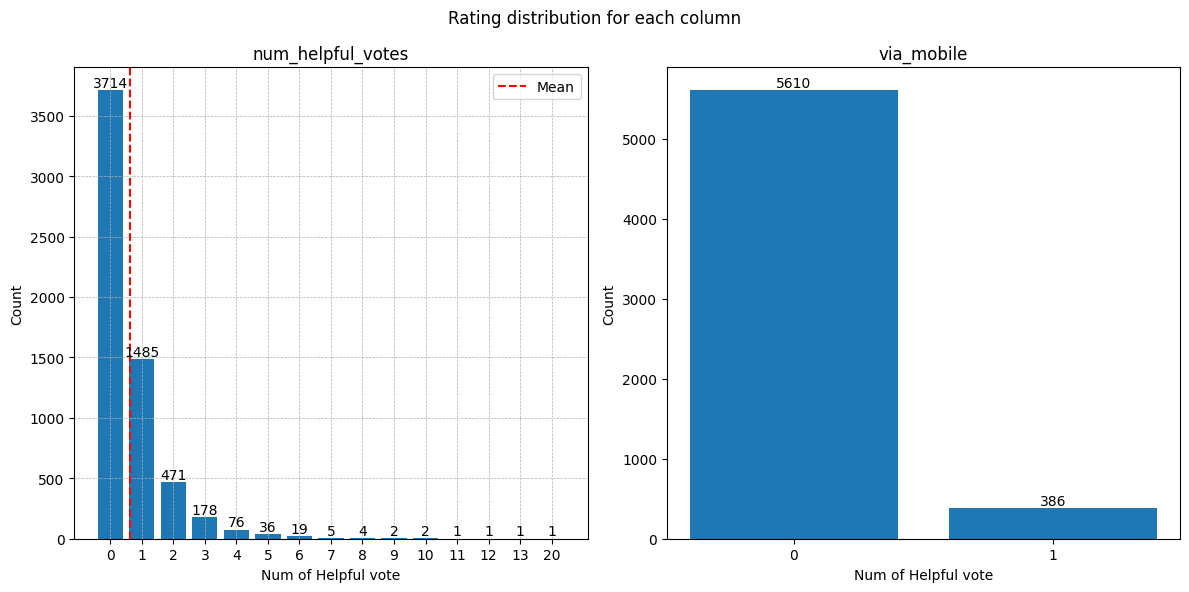

In [16]:
rating_column = [
    'num_helpful_votes',
    'via_mobile',
]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
ax = ax.flatten()

for i, col in enumerate(rating_column):
    mean = reviews_df[col].mean()
    reviews_df_filled = reviews_df[col].fillna('NaN').astype(str)
    counts = reviews_df_filled.value_counts().sort_index(key=lambda x: pd.to_numeric(x, errors='coerce'))
    
    
    bars = ax[i].bar(counts.index, counts.values)
    
    # Add counts on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax[i].text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=10)
    
    if col == 'num_helpful_votes':
        ax[i].axvline(mean, color='red', linestyle='--', label='Mean')
        ax[i].legend()
        
    ax[i].set_title(f'{col}')
    ax[i].set_xlabel('Num of Helpful vote')
    ax[i].set_ylabel('Count')

ax[0].grid(linestyle = '--', linewidth = 0.5)

plt.suptitle('Rating distribution for each column')
plt.tight_layout()
plt.show()

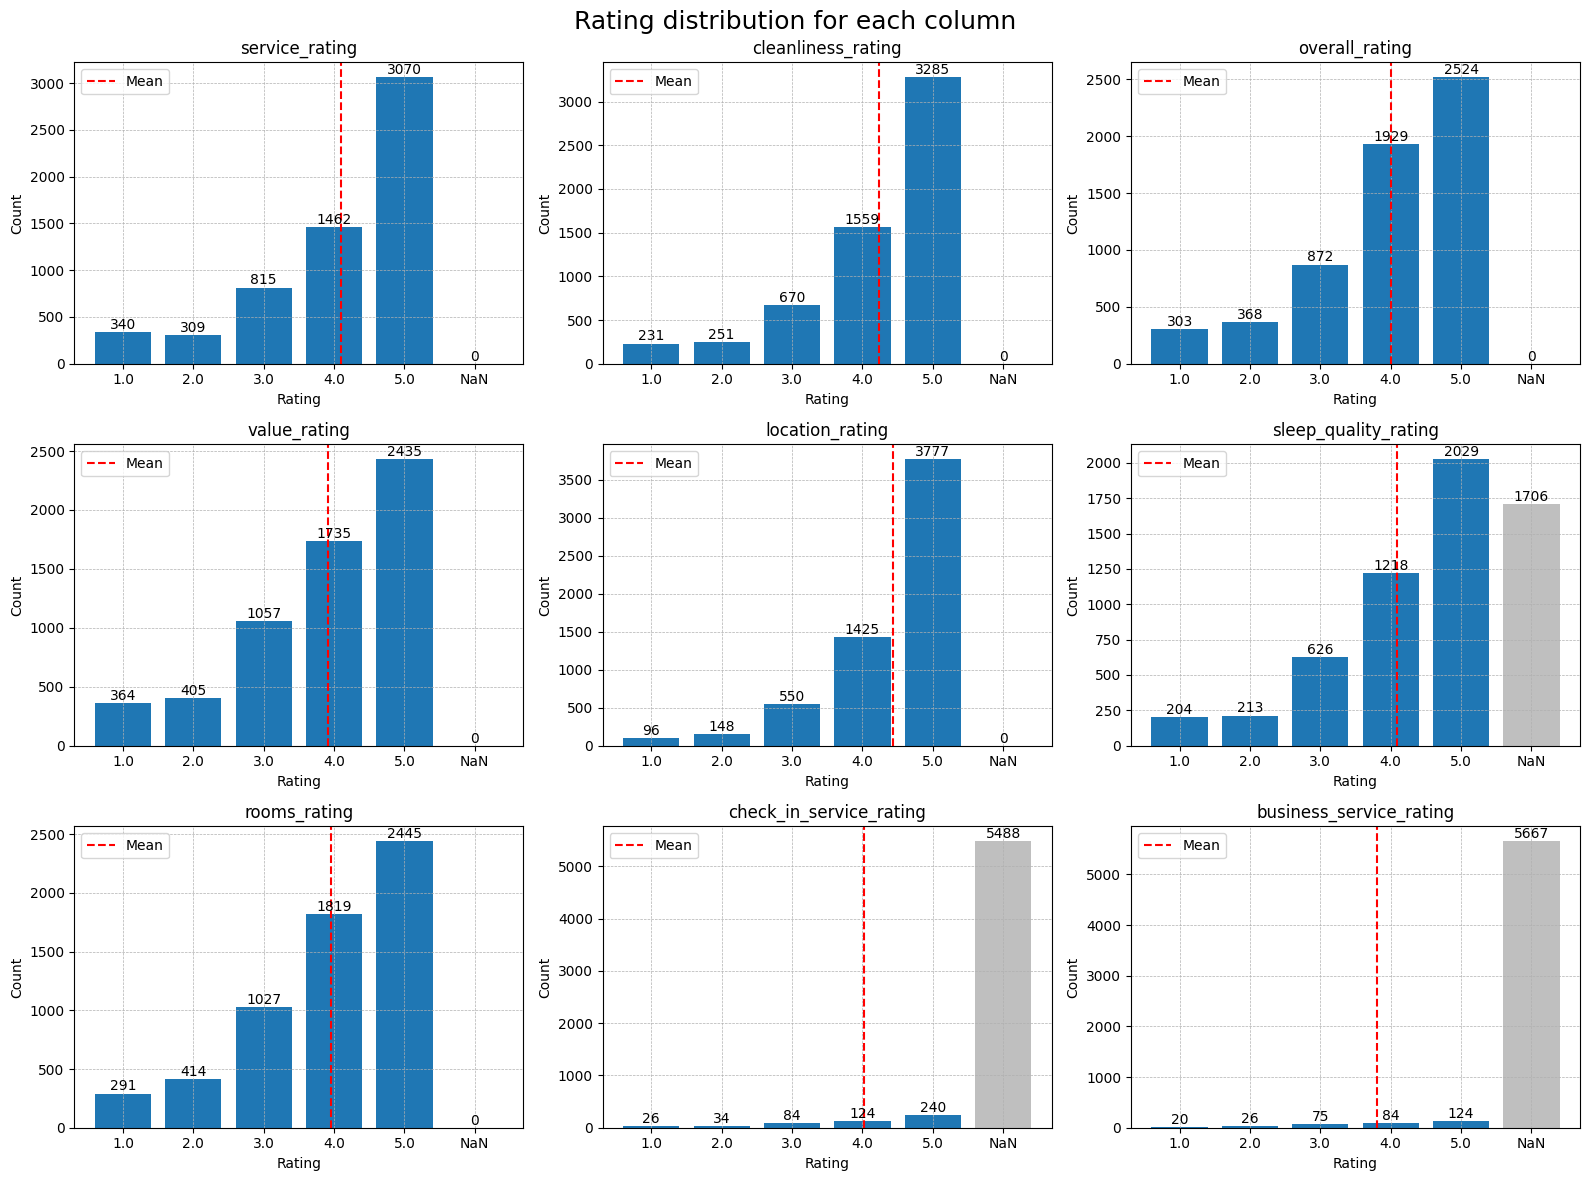

In [17]:
rating_column = [
    'service_rating',
    'cleanliness_rating',
    'overall_rating',
    'value_rating',
    'location_rating',
    'sleep_quality_rating',
    'rooms_rating',
    'check_in_service_rating',
    'business_service_rating'
]

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(16,12))
ax = ax.flatten()

for i, col in enumerate(rating_column):
    mean = reviews_df[col].mean()
    
    reviews_df_filled = reviews_df[col].fillna('NaN').astype(str)
    counts = reviews_df_filled.value_counts()
    
    counts = counts.reindex(['1.0', '2.0', '3.0', '4.0', '5.0', 'NaN'], fill_value=0)
    colors = ['C0'] * 5 + ['gray']
    
    bars = ax[i].bar(counts.index, counts.values, color=colors)
    
    # Add counts on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax[i].text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=10)
    
    # Set the alpha of the NaN to 0.7
    bars[-1].set_alpha(0.5)
    
    # Map numeric mean to bar position
    x_labels = ['1.0', '2.0', '3.0', '4.0', '5.0']
    x_positions = np.arange(len(x_labels))
    
    # Only draw mean if numeric, ignore NaN
    if not np.isnan(mean):
        # Find position on x-axis
        mean_pos = mean - 1  # Subtract position by 1
        ax[i].axvline(mean_pos, color='red', linestyle='--', label='Mean')
        ax[i].legend()
        
    ax[i].set_title(f'{col}')
    ax[i].set_xlabel('Rating')
    ax[i].set_ylabel('Count')
    ax[i].grid(linestyle = '--', linewidth = 0.5)

plt.suptitle('Rating distribution for each column', fontsize=18)
plt.tight_layout()
plt.show()

### Authors Table

In [18]:
authors_df = dataset['authors']
authors_df.head()

,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,id,location,author_key
0,WorldTravelers34,126.0,111.0,429.0,56.0,EAC95C9EA830D7A1BF979AC8B8920313,Chicago,EAC95C9EA830D7A1BF979AC8B8920313|WorldTravelers34
1,Antony T,131.0,639.0,368.0,68.0,11579819C9183DCF5D1BB849DBA61F25,"Tamworth, United Kingdom",11579819C9183DCF5D1BB849DBA61F25|Antony T
2,CynthiafromOhio2011,85.0,955.0,299.0,39.0,F9EEFC1F7666C4B2DA08054E2042C8BC,"Cleveland, Ohio",F9EEFC1F7666C4B2DA08054E2042C8BC|CynthiafromOh...
3,Valux01,94.0,110.0,261.0,94.0,1CF59D870D0E95DF054D928C334154D1,"London, United Kingdom",1CF59D870D0E95DF054D928C334154D1|Valux01
4,イタリアかぶれ,61.0,103.0,250.0,53.0,85B3068C7C1D5DFF69675593D9ABDD9F,埼玉,85B3068C7C1D5DFF69675593D9ABDD9F|イタリアかぶれ


In [19]:
print(f'Number of entries in the authors dataframe: {len(authors_df):,} entries')

authors_df['num_reviews'].sum()
print('ALERT!!! Number of reviews in total are 101,958 but the reviews_sample.db that i am using only has 6,000. this data should not be available in real scenario, might cause data leakage')

Number of entries in the authors dataframe: 5,929 entries
ALERT!!! Number of reviews in total are 101,958 but the reviews_sample.db that i am using only has 6,000. this data should not be available in real scenario, might cause data leakage


In [20]:
authors_df.describe()

,num_cities,num_helpful_votes,num_reviews,num_type_reviews
count,4534.000000,4680.000000,5928.000000,3781.000000
mean,12.496912,17.445726,17.199393,13.793441
std,13.320809,34.878846,25.954881,15.290950
min,2.000000,1.000000,1.000000,3.000000
25%,4.000000,3.000000,2.000000,5.000000
50%,8.000000,7.000000,8.000000,9.000000
75%,16.000000,19.000000,21.000000,16.000000
max,141.000000,955.000000,429.000000,182.000000


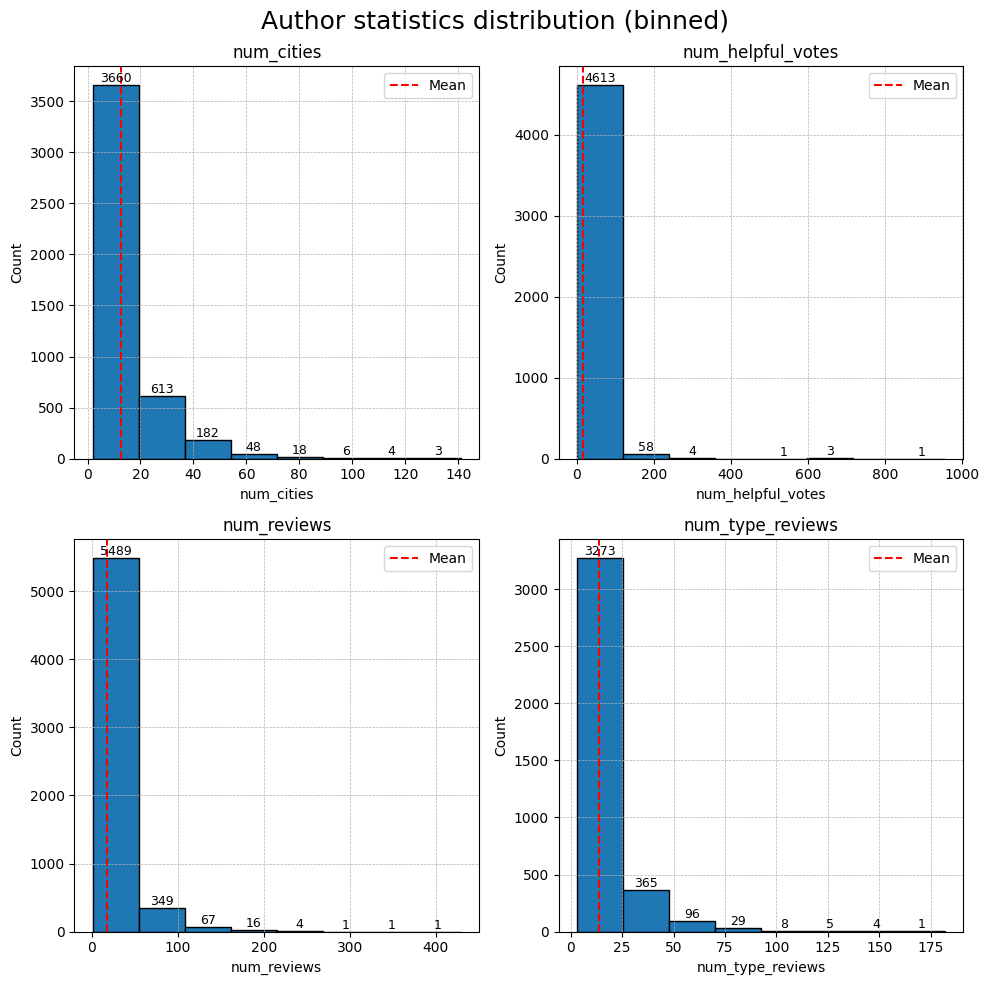

In [21]:
author_column = [
    'num_cities',
    'num_helpful_votes',
    'num_reviews',
    'num_type_reviews'
]

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
ax = ax.flatten()

for i, col in enumerate(author_column):
    mean = authors_df[col].mean()
    
    authors_df_filled = authors_df[col].fillna('NaN').astype(str)
    counts = authors_df_filled.value_counts()
    
    
    counts, bin_edges, bars = ax[i].hist(
        authors_df[col],
        bins=8,
        edgecolor='black'
    )

    # Add count labels on top of bars
    for count, bar in zip(counts, bars):
        if count > 0:
            ax[i].text(
                bar.get_x() + bar.get_width()/2,
                count,
                int(count),
                ha='center',
                va='bottom',
                fontsize=9
            )

    # Mean line
    ax[i].axvline(mean, color='red', linestyle='--', label='Mean')
    ax[i].legend()

    ax[i].set_title(col)
    ax[i].set_xlabel(col)
    ax[i].set_ylabel('Count')
    ax[i].grid(linestyle='--', linewidth=0.5)

plt.suptitle('Author statistics distribution (binned)', fontsize=18)
plt.tight_layout()
plt.show()

### Hotels table

In [22]:
hotels_df = dataset['hotels']
hotels_df.head()

,hotel_id,num_reviews,avg_service_rating,avg_cleanliness_rating,avg_overall_rating,avg_value_rating,avg_location_rating,avg_sleep_quality_rating,avg_rooms_rating
0,214197,2624,2.399390,2.342226,2.363567,2.737805,4.492759,2.682187,2.131479
1,122005,2395,3.908559,4.206681,3.983299,3.886013,4.691441,4.117004,3.720251
2,93618,2300,4.015652,4.141304,3.899565,3.456957,4.634783,4.149271,3.744783
3,93520,2168,3.518450,3.622694,3.588561,3.588100,4.696033,3.838451,3.499077
4,93562,2044,4.235323,4.213307,4.088063,4.014677,4.684932,3.942877,4.002935


num_reviews


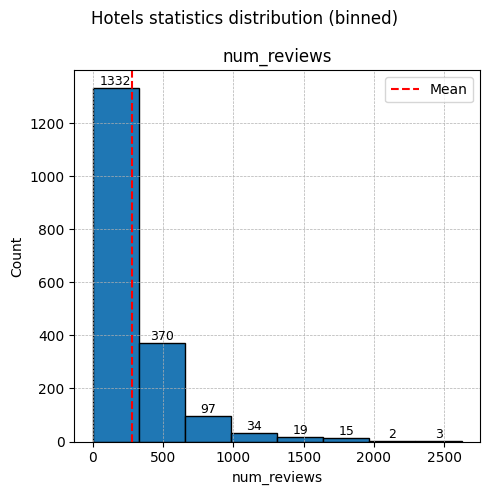

In [23]:
hotel_column = [
    'num_reviews',
]

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,5))

for i, col in enumerate(hotel_column):
    print(col)
    mean = hotels_df[col].mean()
    
    hotels_df_filled = hotels_df[col].fillna('NaN').astype(str)
    counts = hotels_df_filled.value_counts()
    
    
    counts, bin_edges, bars = ax.hist(
        hotels_df[col],
        bins=8,
        edgecolor='black'
    )

    # Add count labels on top of bars
    for count, bar in zip(counts, bars):
        if count > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                count,
                int(count),
                ha='center',
                va='bottom',
                fontsize=9
            )

    # Mean line
    ax.axvline(mean, color='red', linestyle='--', label='Mean')
    ax.legend()

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.grid(linestyle='--', linewidth=0.5)

plt.suptitle('Hotels statistics distribution (binned)')
plt.tight_layout()
plt.show()

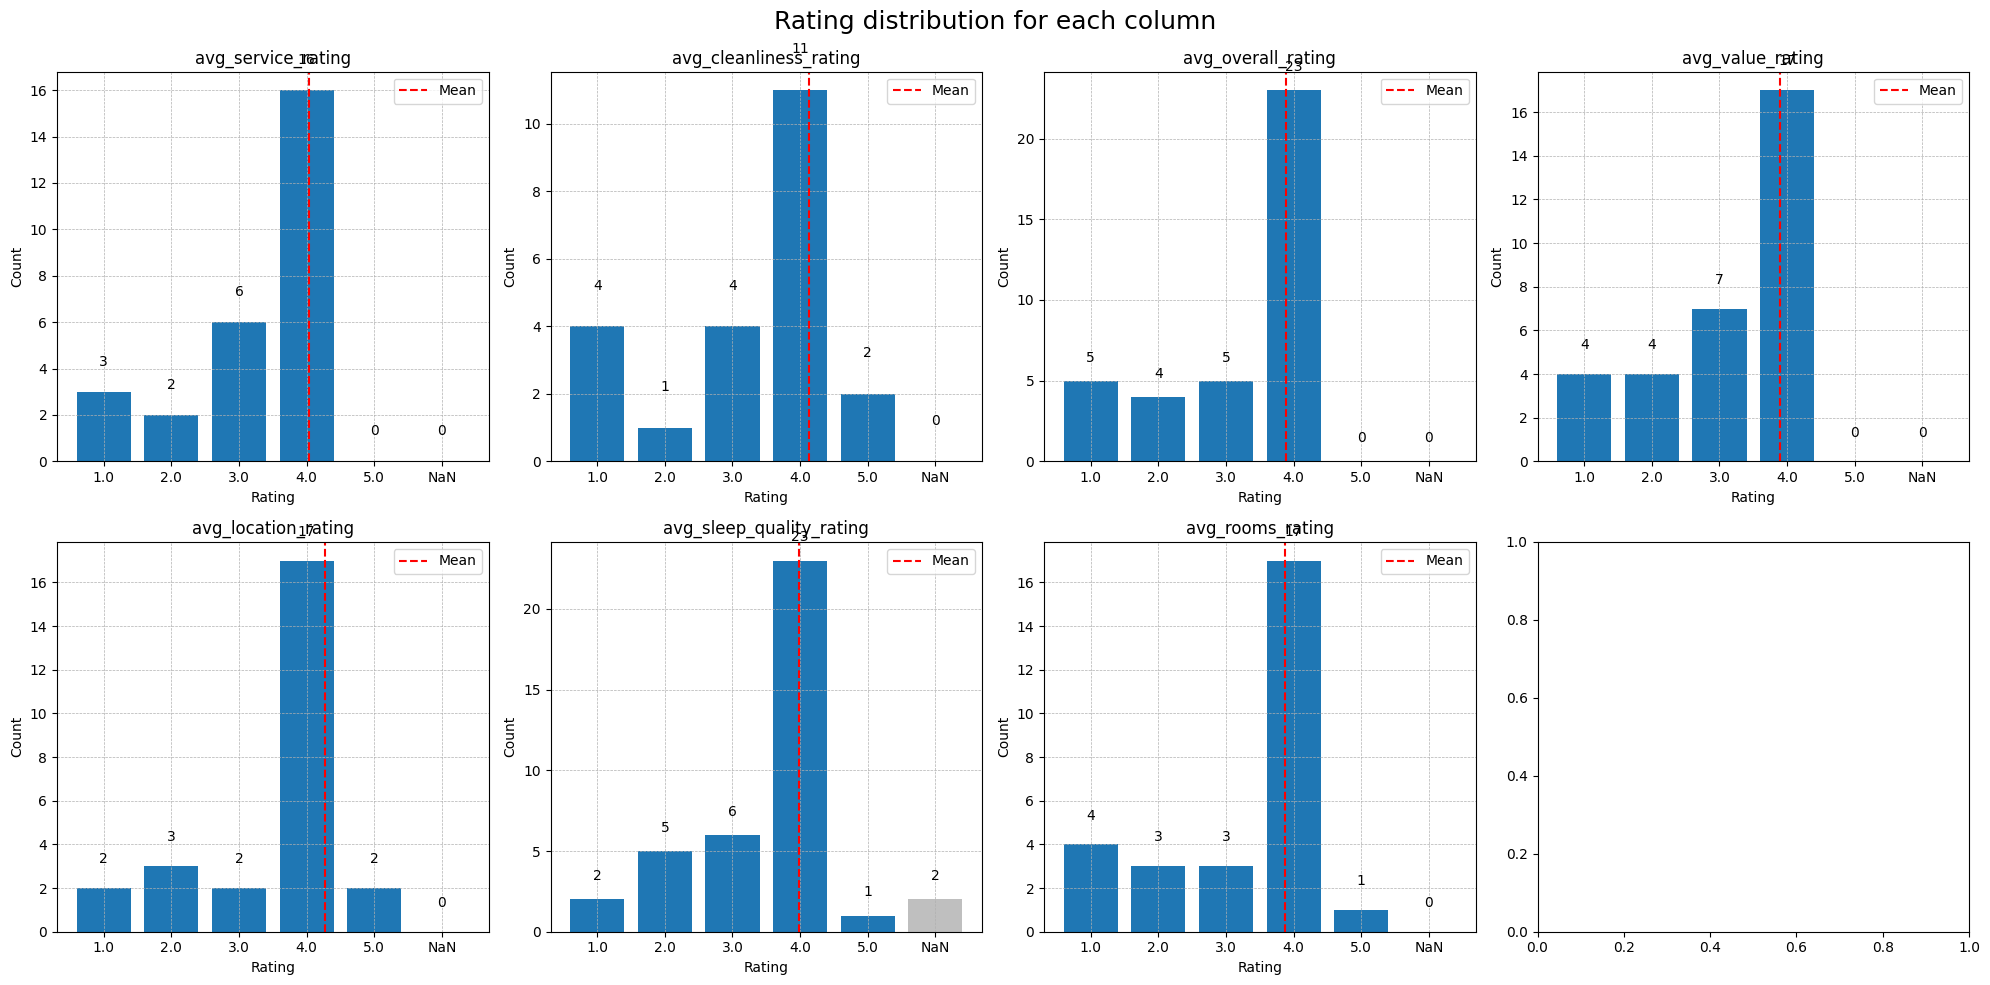

In [24]:
hotel_column = [
    'avg_service_rating',
    'avg_cleanliness_rating',
    'avg_overall_rating',
    'avg_value_rating',
    'avg_location_rating',
    'avg_sleep_quality_rating',
    'avg_rooms_rating',
]

fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(20,10))
ax = ax.flatten()

for i, col in enumerate(hotel_column):
    mean = hotels_df[col].mean()
    
    hotels_df_filled = hotels_df[col].fillna('NaN').astype(str)
    counts = hotels_df_filled.value_counts()
    
    counts = counts.reindex(['1.0', '2.0', '3.0', '4.0', '5.0', 'NaN'], fill_value=0)
    colors = ['C0'] * 5 + ['gray']
    
    bars = ax[i].bar(counts.index, counts.values, color=colors)
    
    # Add counts on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax[i].text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=10)
    
    # Set the alpha of the NaN to 0.7
    bars[-1].set_alpha(0.5)
    
    # Map numeric mean to bar position
    # x_labels = ['1.0', '2.0', '3.0', '4.0', '5.0']
    # x_positions = np.arange(len(x_labels))
    
    # Only draw mean if numeric, ignore NaN
    if not np.isnan(mean):
        # Find position on x-axis
        mean_pos = mean - 1  # Subtract position by 1
        ax[i].axvline(mean_pos, color='red', linestyle='--', label='Mean')
        ax[i].legend()
        
    ax[i].set_title(f'{col}')
    ax[i].set_xlabel('Rating')
    ax[i].set_ylabel('Count')
    ax[i].grid(linestyle = '--', linewidth = 0.5)

plt.suptitle('Rating distribution for each column', fontsize=18)
plt.tight_layout()
plt.show()

---

## 3. Feature Engineering

**is_frequent_reviewer** in the authors_df

**helpful_votes_per_review** in the authors_df

**avg_stars_given** in the authors_df

**ratings_variance** in the hotels_df to make sure the rating is consistent

**distance_from_avg** in the reviews_df ratings

---

## 4. Analytics by Business Questions

### **a. How does the hotel rating differ by location?**

ALERT!!! Location is not in the hotels_df

### **b. Best and worst hotels from each service category?**

### **c. Repeating visitor? mobile vs non mobile? fast and late review (3 mos threshold)?**

### **d. Best compliment Keyword for each hotels?**

My idea is to normalize the reviews, and check using tf-idf

In [25]:
#

### **e. Which rating category contributes the most to the overall rating?**

check the correlation of the scores. this can help the hotel to decide where to invest next

### **f. Trend in the stars during the years for each hotel or for each location group**

### **g. "How does my hotel perform?"**

by inputting the average rating of the current hotel, we can show graph like "you perform better than 90% of hotels worldwide, and 95% in the same region".

### **h. top 5 hotel and bottom 5 hotel per location**

### **i. best and worst service per location to tell which countries are better in certain category**

### **j. does mobile reviews is shorter and less helpful?**

### **k. Do fast reviews tend to be more negative?**

### **l. are experienced travelers more critical than casual reviewers?**

---

Column Explanation:
* title
* text
* date_stayed
* hotel_id
* num_helpful_votes
* review_date
* review_id
* via_mobile
* service_rating
* cleanliness_rating
* overall_rating
* value_rating
* location_rating
* sleep_quality_rating
* rooms_rating
* check_in_service_rating
* business_service_rating
* author_key

### Close connection

In [26]:
conn.close()

Issue:
- is the location denotes the hotel's location or the user
- where is the complete dataset .db
- data validation step is still incomplete (date checking and else)
- column description step is missing yet essential for us to make
- feature engineering part needs more ideas